## **Pomocne moduly**

In [16]:
import itertools
import math
import numpy as np
import UQpy
from scipy.special import comb
from UQpy.distributions import Uniform,Normal, JointIndependent
from UQpy.surrogates.polynomial_chaos import TotalDegreeBasis, LeastSquareRegression
from UQpy.sensitivity import PceSensitivity
from UQpy.sampling import MonteCarloSampling
from sklearn.metrics import mean_squared_error, r2_score
import time  
import scipy as sp
import random
import matplotlib.pyplot as plt

import SAPCE

In [18]:

def root_mean_squared_error(y_true, y_pred, multioutput='uniform_average'):
    mse = mean_squared_error(y_true, y_pred, multioutput=multioutput)
    if isinstance(mse, np.ndarray):
        return np.sqrt(mse)
    return np.sqrt(mse)


X shape: (1000, 12)
Y_N shape: (1000, 113)
dtype X: float64
dtype Y_N: float64
Replication 1/50
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: design matrix not sufficiently well-

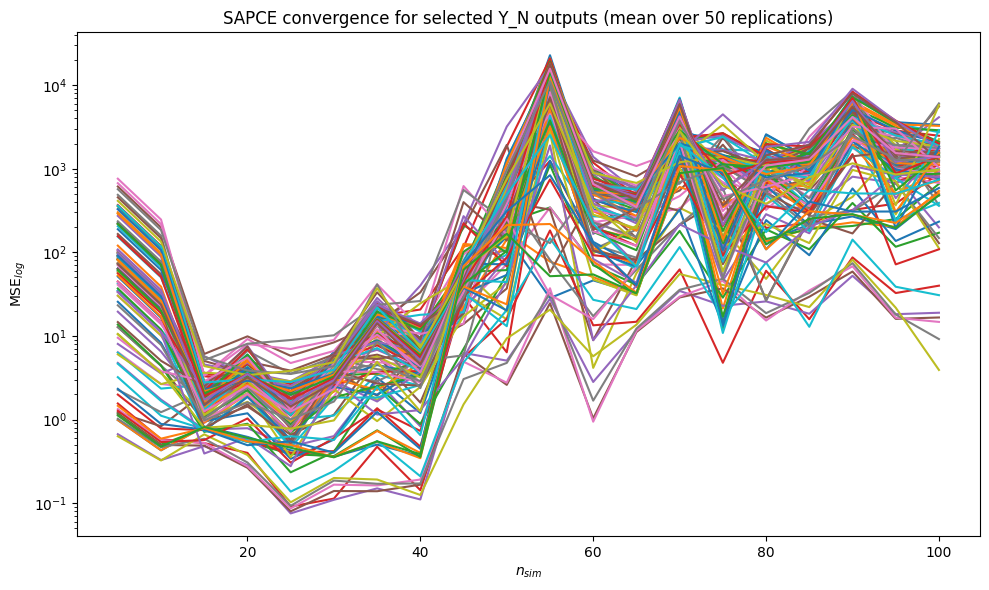

Single run 1/1
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: design matrix not sufficiently well-conditioned: 1695.203104824548
Adaptive basis construction terminated: basis cardinality reached experimental design size.
Adaptive basis construction terminated: design matrix not sufficiently well-conditioned: 5432845678582937.0
Adaptive basis construction termin

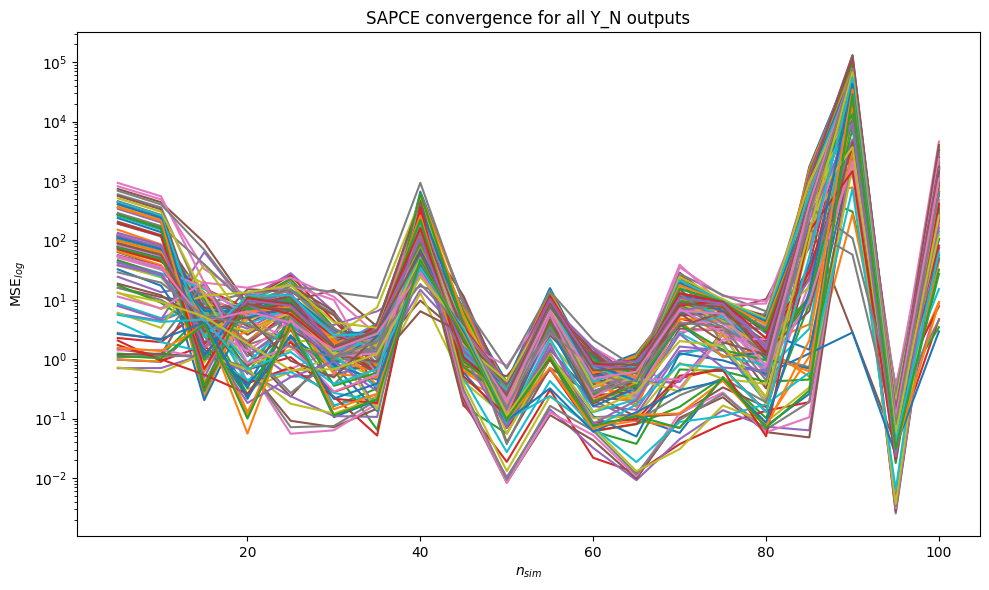

In [19]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from UQpy.distributions import Normal, Uniform, JointIndependent
import SAPCE


# --------------------------------------------------
# Settings
# --------------------------------------------------
seed = 1
n_replications = 50
n_steps = 20
step_size = 5

max_partial_degree = 10
max_condition_number = 1e3
pruning_criterion = 1e-8

random.seed(seed)
np.random.seed(seed)


# --------------------------------------------------
# Load data
# --------------------------------------------------
data_NVM = pd.read_csv("Oakwood_M.csv", sep=";", header=0)

# převod všech object sloupců: desetinná čárka -> tečka, pak na číslo
for col in data_NVM.columns:
    if data_NVM[col].dtype == object:
        data_NVM[col] = pd.to_numeric(
            data_NVM[col].astype(str).str.replace(",", ".", regex=False),
            errors="raise"
        )

names_NVM = data_NVM.columns.tolist()
data_array_NVM = data_NVM.to_numpy(dtype=float)

# Inputs
X = data_array_NVM[:, :12]

# Outputs: use only Y_N
Y_all_NVM = data_array_NVM[:, 12:]
Y_N = Y_all_NVM[:, :113]

print("X shape:", X.shape)
print("Y_N shape:", Y_N.shape)
print("dtype X:", X.dtype)
print("dtype Y_N:", Y_N.dtype)

n_selected_curves = Y_N.shape[1]
# --------------------------------------------------
# Input distributions
# --------------------------------------------------

# Concrete parameters
dist_Ec=Normal(13,1)
dist_Relax=Uniform(30,40)

# Soil1
dist_S1_Erel=Uniform(2,1)
dist_S1_E50=Normal(65,5)
dist_S1_c=Normal(30,5)
dist_S1_theta=Normal(30,1)
dist_S1_ko=Uniform(0.6,0.5)

# Soil2
dist_S2_Erel=Uniform(2,1)
dist_S2_E50=Normal(130,10)
dist_S2_c=Normal(5,1)
dist_S2_theta=Normal(42,1)
dist_S2_ko=Uniform(0.45,0.2)


marg = [dist_Ec,dist_Relax, dist_S1_Erel, dist_S1_E50, dist_S1_c,dist_S1_theta,dist_S1_ko,dist_S2_Erel,dist_S2_E50,dist_S2_c,dist_S2_theta,dist_S2_ko]
joint = JointIndependent(marginals=marg)

# --------------------------------------------------
# Helper function
# --------------------------------------------------
def split_train_validation(X, Y, n_train):
    all_indices = list(range(len(Y)))
    train_indices = random.sample(all_indices, n_train)

    mask = np.ones(len(Y), dtype=bool)
    mask[train_indices] = False

    xx_train = X[train_indices, :]
    yy_train = Y[train_indices, :]

    xx_val = X[mask, :]
    yy_val = Y[mask, :]

    return xx_train, yy_train, xx_val, yy_val


def fit_and_validate(xx_train, yy_train, xx_val, yy_val, joint):
    sapce = SAPCE.SensitivityAdaptivePCE(
        pdf=joint,
        exp_design_in=xx_train,
        exp_design_out=yy_train,
        max_partial_degree=max_partial_degree,
        num_inputs=12
    )

    sapce.construct_adaptive_basis(max_condition_number=max_condition_number)
    sapce.construct_pruned_pce(cr=pruning_criterion)

    err = sapce.pce.validation_error(xx_val, yy_val)
    return err


# --------------------------------------------------
# Statistical replications
# --------------------------------------------------
errs_stat = []
nsim = [step_size * i for i in range(1, n_steps + 1)]

for s in range(n_replications):
    print(f"Replication {s + 1}/{n_replications}")
    errs = []

    for n_train in nsim:
        xx_train, yy_train, xx_val, yy_val = split_train_validation(X, Y_N, n_train)

        err = fit_and_validate(xx_train, yy_train, xx_val, yy_val, joint)
        errs.append(err)

    errs_stat.append(errs)

errs_stat_array = np.array(errs_stat)

print("errs_stat_array shape (replications):", errs_stat_array.shape)


# --------------------------------------------------
# Plot selected outputs (mean over replications)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

n_curves_to_plot = min(n_selected_curves, Y_N.shape[1])

for i in range(n_curves_to_plot):
    ax.plot(
        nsim,
        np.mean(errs_stat_array[:, :, i], axis=0),
        label=f"output {i + 1}"
    )

ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$")
ax.set_xlabel("$n_{sim}$")
ax.set_title("SAPCE convergence for selected Y_N outputs (mean over 50 replications)")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Single run for all Y_N outputs
# --------------------------------------------------
errs_stat_single = []

for s in range(1):
    print(f"Single run {s + 1}/1")
    errs = []

    for n_train in nsim:
        xx_train, yy_train, xx_val, yy_val = split_train_validation(X, Y_N, n_train)

        err = fit_and_validate(xx_train, yy_train, xx_val, yy_val, joint)
        errs.append(err)

    errs_stat_single.append(errs)

errs_stat_array_single = np.array(errs_stat_single)

print("errs_stat_array shape (single run):", errs_stat_array_single.shape)


# --------------------------------------------------
# Plot all 113 output curves
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

n_outputs = Y_N.shape[1]

for i in range(n_outputs):
    ax.plot(
        nsim,
        np.mean(errs_stat_array_single[:, :, i], axis=0),
        label=f"output {i + 1}"
    )

print("Number of curves:", n_outputs)

ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$")
ax.set_xlabel("$n_{sim}$")
ax.set_title("SAPCE convergence for all Y_N outputs")
plt.tight_layout()
plt.show()

In [20]:
# Index posledního sloupce z původních 113 výstupů v rámci celého data_array_NVM
# prvních 12 sloupců = X, další výstupy začínají od indexu 12
col_idx_in_full = 12 + 112

print("Index v celém datasetu:", col_idx_in_full)
print("Název sloupce:", names_NVM[col_idx_in_full])

last_col_113 = data_array_NVM[:, col_idx_in_full]

print("Tvar sloupce:", last_col_113.shape)
print("Hodnoty:")
print(last_col_113)

Index v celém datasetu: 124
Název sloupce: SM_6653_19
Tvar sloupce: (1000,)
Hodnoty:
[ 1.24130090e+04  6.45739300e+03 -1.96250680e+03 -8.06455370e+03
 -3.95576700e+03  3.79348320e+03  4.57607000e+03  1.20512150e+04
  3.98882520e+03  3.29357300e+03 -2.96060280e+03  1.36382230e+04
  1.73525550e+04  1.25205625e+04  9.83818100e+03  3.61363130e+03
  1.26120460e+04  1.76176750e+03  1.18984860e+04  1.44856950e+04
  1.57360850e+04  2.11602420e+03  1.32950050e+04  7.31036100e+03
  7.27161470e+03  3.02262840e+03  1.87819910e+03 -7.39639300e+03
  1.17339780e+03  3.29583980e+03  3.33513770e+03  1.70355410e+04
  9.74837800e+03  8.12508500e+03  8.61050700e+03  7.30565140e+03
 -8.42968100e+03  1.00010630e+04  9.15114500e+03  1.42776140e+03
  7.86602900e+02  1.44345360e+04  1.29709090e+04  1.39702970e+03
  5.83402640e+03  1.15623580e+03  6.87060300e+03  8.02698300e+03
  1.00926180e+04  1.54345150e+03  1.19827510e+04  1.12258880e+04
 -3.35775460e+03  1.28821290e+03  6.53626460e+03 -3.11761500e+03
  5.4